In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

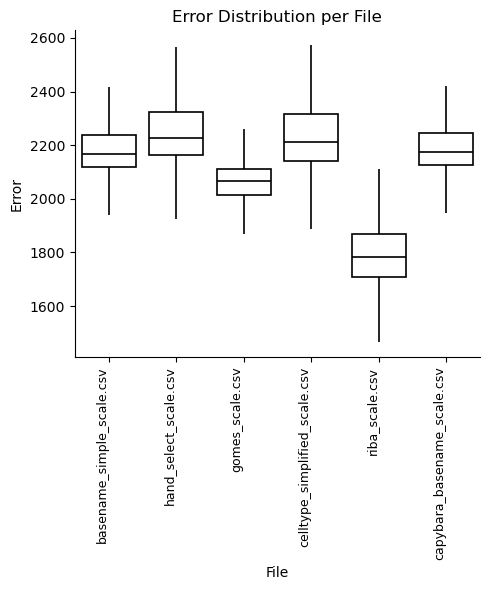

In [13]:


dpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/"
file_list = glob.glob(f"{dpath}*scale*")

# Read as dictionary keyed by basename
dfs = {os.path.basename(f): pd.read_csv(f, sep=None, engine='python') for f in file_list}

# Prepare combined dataframe for seaborn boxplot
plot_data = []
for name, df in dfs.items():
    if "Error" in df.columns:
        for v in df["Error"].dropna():
            plot_data.append({"File": name, "Error": v})

plot_df = pd.DataFrame(plot_data)

plt.figure(figsize=(5, 6))
sns.boxplot(
    data=plot_df,
    x="File",
    y="Error",
    color="white",
    linewidth=1.2,
    linecolor='k',
    showfliers=False,
    capprops={'lw' : 0},
)
plt.xticks(rotation=90, ha='right', fontsize=9)
plt.xlabel("File")
plt.ylabel("Error")
plt.title("Error Distribution per File")
plt.tight_layout()
sns.despine()
plt.show()
